In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
import zipfile

zip_path = "/content/archive (1).zip"
extract_path = "/content/tomato_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import os

dataset_path = "/content/tomato_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    break

/content/tomato_dataset


In [4]:
os.listdir("/content/tomato_dataset")

['tomato']

In [5]:
os.listdir("/content/tomato_dataset/tomato")

['val', 'train', 'cnn_train.py']

In [6]:
train_path = "/content/tomato_dataset/tomato/train"
val_path = "/content/tomato_dataset/tomato/val"

print("Train Path:", train_path)
print("Validation Path:", val_path)

Train Path: /content/tomato_dataset/tomato/train
Validation Path: /content/tomato_dataset/tomato/val


In [7]:
import os

print(os.listdir(train_path))

['Tomato___Bacterial_spot', 'Tomato___Septoria_leaf_spot', 'Tomato___Early_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus']


In [8]:
import os

for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

Tomato___Bacterial_spot : 1000
Tomato___Septoria_leaf_spot : 1000
Tomato___Early_blight : 1000
Tomato___Leaf_Mold : 1000
Tomato___healthy : 1000
Tomato___Late_blight : 1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 1000
Tomato___Spider_mites Two-spotted_spider_mite : 1000
Tomato___Target_Spot : 1000
Tomato___Tomato_mosaic_virus : 1000


In [9]:
for folder in os.listdir(val_path):
    folder_path = os.path.join(val_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

Tomato___Bacterial_spot : 100
Tomato___Septoria_leaf_spot : 100
Tomato___Early_blight : 100
Tomato___Leaf_Mold : 100
Tomato___healthy : 100
Tomato___Late_blight : 100
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 100
Tomato___Spider_mites Two-spotted_spider_mite : 100
Tomato___Target_Spot : 100
Tomato___Tomato_mosaic_virus : 100


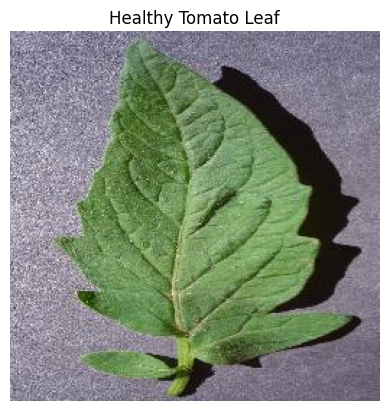

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

healthy_path = os.path.join(
    train_path,
    "Tomato___healthy"
)

healthy_image = os.listdir(healthy_path)[0]

img = mpimg.imread(
    os.path.join(healthy_path, healthy_image)
)

plt.imshow(img)
plt.title("Healthy Tomato Leaf")
plt.axis("off")
plt.show()

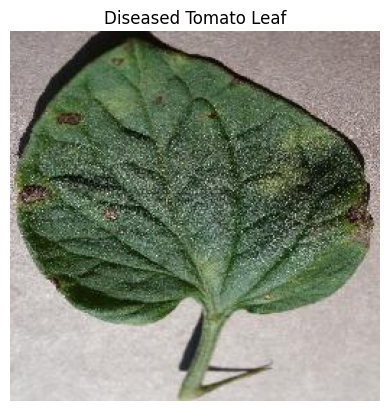

In [11]:
disease_path = os.path.join(
    train_path,
    "Tomato___Early_blight"
)

disease_image = os.listdir(disease_path)[0]

img = mpimg.imread(
    os.path.join(disease_path, disease_image)
)

plt.imshow(img)
plt.title("Diseased Tomato Leaf")
plt.axis("off")
plt.show()

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)

Found 10000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.


In [13]:
import shutil
import os

binary_path = "/content/binary_tomato_dataset"

train_binary_path = os.path.join(binary_path, "train")
val_binary_path = os.path.join(binary_path, "val")

for split_path in [train_binary_path, val_binary_path]:
    os.makedirs(os.path.join(split_path, "Healthy"), exist_ok=True)
    os.makedirs(os.path.join(split_path, "Diseased"), exist_ok=True)

print("Binary dataset folders created successfully!")

Binary dataset folders created successfully!


In [14]:
for folder in os.listdir(train_path):

    source_folder = os.path.join(train_path, folder)

    if folder == "Tomato___healthy":
        destination_folder = os.path.join(train_binary_path, "Healthy")
    else:
        destination_folder = os.path.join(train_binary_path, "Diseased")

    for image in os.listdir(source_folder):
        shutil.copy(
            os.path.join(source_folder, image),
            os.path.join(destination_folder, image)
        )

print("Training dataset converted to binary successfully!")

Training dataset converted to binary successfully!


In [15]:
for folder in os.listdir(val_path):

    source_folder = os.path.join(val_path, folder)

    if folder == "Tomato___healthy":
        destination_folder = os.path.join(val_binary_path, "Healthy")
    else:
        destination_folder = os.path.join(val_binary_path, "Diseased")

    for image in os.listdir(source_folder):
        shutil.copy(
            os.path.join(source_folder, image),
            os.path.join(destination_folder, image)
        )

print("Validation dataset converted to binary successfully!")

Validation dataset converted to binary successfully!


In [16]:
print("Training Healthy:", len(os.listdir(os.path.join(train_binary_path, "Healthy"))))
print("Training Diseased:", len(os.listdir(os.path.join(train_binary_path, "Diseased"))))
print("Validation Healthy:", len(os.listdir(os.path.join(val_binary_path, "Healthy"))))
print("Validation Diseased:", len(os.listdir(os.path.join(val_binary_path, "Diseased"))))

Training Healthy: 1000
Training Diseased: 9000
Validation Healthy: 100
Validation Diseased: 900


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight"
]

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    classes=selected_classes
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    classes=selected_classes
)

Found 2000 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7640 - loss: 0.4504 - val_accuracy: 0.9850 - val_loss: 0.0678
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9620 - loss: 0.1105 - val_accuracy: 0.9800 - val_loss: 0.0282
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9860 - loss: 0.0524 - val_accuracy: 0.9850 - val_loss: 0.0728
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 988ms/step - accuracy: 0.9800 - loss: 0.0505 - val_accuracy: 0.9850 - val_loss: 0.0485
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9875 - loss: 0.0348 - val_accuracy: 0.9900 - val_loss: 0.0248
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9850 - loss: 0.0407 - val_accuracy: 0.9800 - val_loss: 0.0509
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9955 - loss: 0.0113 - val_accuracy: 0.9850 - val_loss: 0.0393
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9865 - loss: 0.0354 - val_accuracy: 0.9800 - val_lo

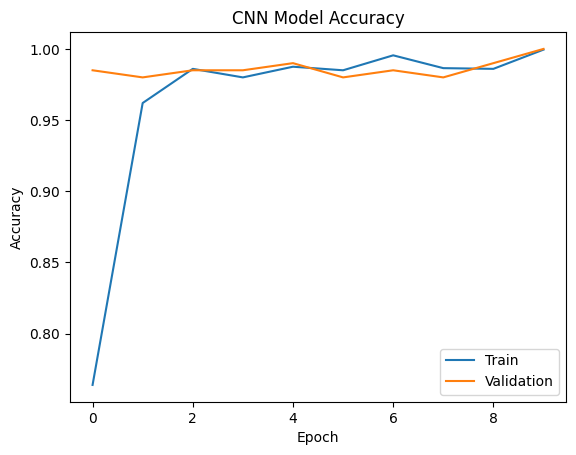

In [20]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

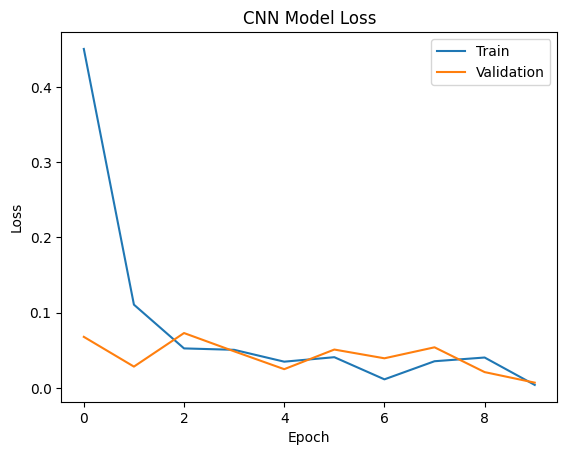

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
from sklearn.metrics import classification_report
import numpy as np

predictions = cnn_model.predict(val_generator)

predicted_classes = (predictions > 0.5).astype(int)

true_classes = val_generator.classes

print(classification_report(true_classes, predicted_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 786ms/step
              precision    recall  f1-score   support

           0       0.44      0.44      0.44       100
           1       0.44      0.44      0.44       100

    accuracy                           0.44       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.44      0.44      0.44       200



In [24]:
val_generator_eval = val_datagen.flow_from_directory(
    val_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    classes=selected_classes,
    shuffle=False
)

predictions = cnn_model.predict(val_generator_eval)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

true_classes = val_generator_eval.classes

print(classification_report(true_classes, predicted_classes))

Found 200 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



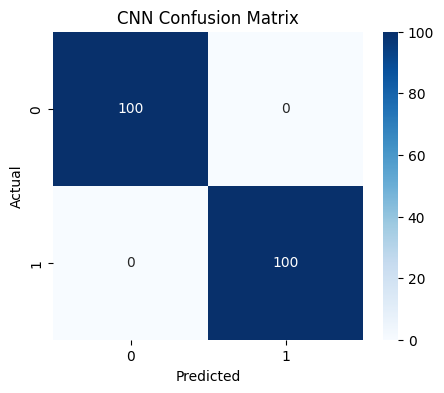

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 468ms/step - accuracy: 0.9235 - loss: 0.2393 - val_accuracy: 0.9550 - val_loss: 0.1325
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 436ms/step - accuracy: 0.9725 - loss: 0.1035 - val_accuracy: 0.9750 - val_loss: 0.0915
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 439ms/step - accuracy: 0.9785 - loss: 0.0758 - val_accuracy: 0.9800 - val_loss: 0.0713
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 454ms/step - accuracy: 0.9840 - loss: 0.0599 - val_accuracy: 0.9850 - val_loss: 0.0613
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 28s 450ms/step - accuracy: 0.9870 - loss: 0.0497 - val_accuracy: 0.9900 - val_loss: 0.0570


In [28]:
val_generator_eval = val_datagen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    classes=selected_classes,
    shuffle=False
)

predictions = mobilenet_model.predict(val_generator_eval)

predicted_classes = (predictions > 0.5).astype(int).reshape(-1)

from sklearn.metrics import classification_report

print(classification_report(
    val_generator_eval.classes,
    predicted_classes
))

Found 200 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 747ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

